# 3. Unsupervised Learning

In this notebook we will apply different unsupervised learning techniques to analyze the main structure of our dataset, evaluating principal components and their associated variance, thus determining the dataset's optimal dimensionality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14})
warnings.filterwarnings('ignore') 

We first load the dataset and split the predictors from the target variable:

In [2]:
df = pd.read_csv('../data/preprocessed.csv')
X = df.drop(columns=['log_shares'])
y = df['log_shares']

## 3.1 PCA
We start by applying PCA to determine the principal components of our dataset and evaluate their explained variance, thus finding the optimal number of dimensions to retain. We will also mark the thresholds required to retain 80%, 90%, and 95% of the dataset's total variance.

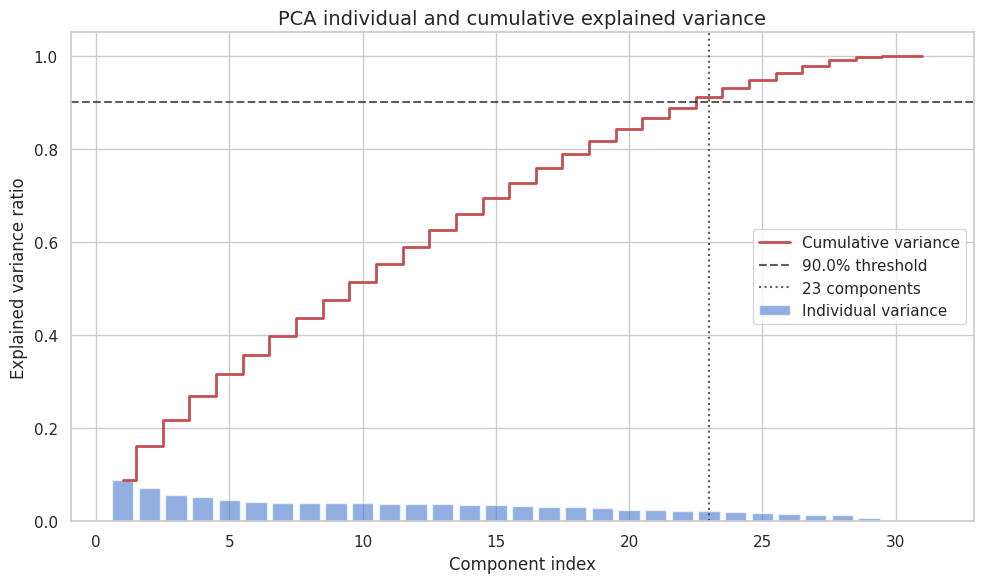

Total original features: 31
Components required for 90% variance: 23


In [3]:
# Fit PCA
pca_full = PCA(random_state=42)
pca_full.fit(X)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot individual and cumulative variances
plt.figure()
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, label='Individual variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', color='#C44E52', linewidth=2, label='Cumulative variance')

# Mark the 90% threshold for cumulative variance
threshold = 0.90
n_comps = np.argmax(cumulative_variance >= threshold) + 1

plt.axhline(y=threshold, color='k', linestyle='--', alpha=0.7, label=f'{threshold*100}% threshold')
plt.axvline(x=n_comps, color='k', linestyle=':', alpha=0.7, label=f'{n_comps} components')

# Formatting
plt.title('PCA individual and cumulative explained variance')
plt.xlabel('Component index')
plt.ylabel('Explained variance ratio')
plt.ylim(0, 1.05)
plt.legend(loc='center right')
plt.tight_layout()
plt.show()

print(f"Total original features: {X.shape[1]}")
print(f"Components required for {int(threshold*100)}% variance: {n_comps}")

Observing the indidicual and cumulative variance curve, we can extract multiple key characteristics from our dataset:

* **Absence of a dominant component:** The first principal component ($PC_1$) explain less than 10% of the total variance, and following components show a very smooth, decreasing tail in their individual variances. There is no single dominant factor characterizing this dataset.
* **Distributed variance:** We also note the lack of a sharp elbow that indicates the dataset's information is highly distributed across many dimensions. This is likely caused by our preprocessing, as by removing highly collinear features, we distributed the variance across the remaining features.
* **Dimensionality reduction threshold:** To retain 90% of the variance, the model needs 23 principal components. Given that our dataset after preprocessing contains 31 features, reducing the space to 23 dimensions would not be considered as a high compression, so for downstream modelling, we will keep all the variables in our preprocessed dataset.

## 3.2 Clustering Analysis

To discover underlying clusters within our dataset, we apply K-Means and GMM as unsupervised clustering techniques. 

Before fitting the models, we must determine the optimal number of clusters ($K$). We evaluate K-Means across a range of $K$ values using two metrics:
1. **The elbow method (Inertia):** Measures the within-cluster sum of squares (WSS). We look for the "elbow" where adding more clusters leads to less compacted groups.
2. **The Silhouette score:** Indicates how well separated the clusters are. A higher score indicates that objects are similar to their cluster and dissimilar to other clusters.

Evaluating cluster metrics...


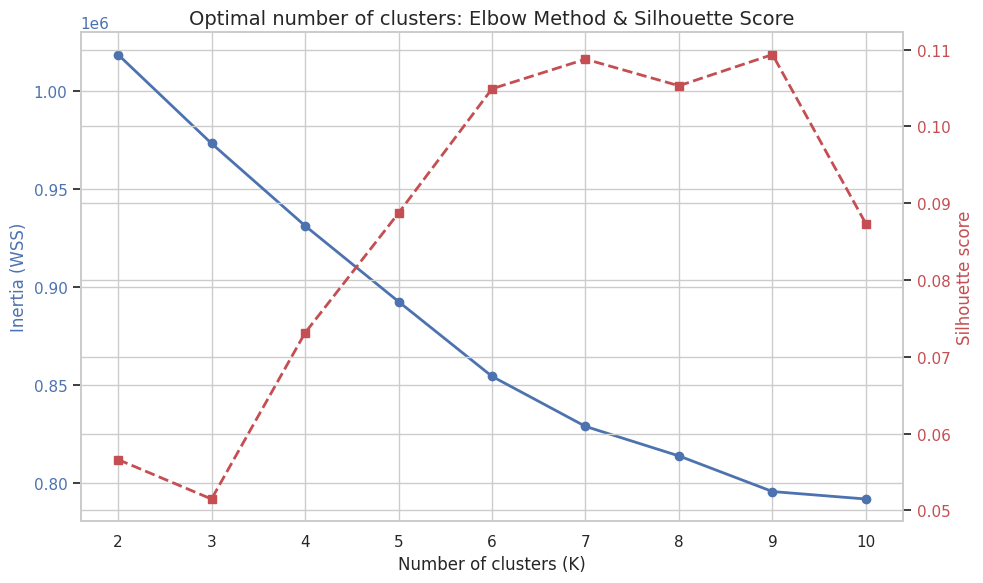

In [4]:
k_values = range(2, 11)
inertia_values = []
silhouette_scores = []

print("Evaluating cluster metrics...")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

fig, ax1 = plt.subplots(figsize=(10, 6))
color = '#4C72B0'
ax1.set_xlabel('Number of clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (WSS)', color=color, fontsize=12)
ax1.plot(k_values, inertia_values, marker='o', color=color, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#C44E52'
ax2.set_ylabel('Silhouette score', color=color, fontsize=12)
ax2.plot(k_values, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimal number of clusters: Elbow Method & Silhouette Score', fontsize=14)
fig.tight_layout()
plt.show()

* **Inertia (elbow method):** The inertia curve shows a smooth decreasing curve as the number of clusters increases. Although we can see there is no a sharp elbow, the curve begins to flatten around $K=6$ and $K=7$, but the lack of a sharp elbow indicates that the dataset does not contain highly compacted clusters.
* **Silhouette Score:** The absolute values of the silhouette scores are low across all values of $K$ (with a maximum of $0.11$), which likely indicates that the clusters are overlapping, and most data points are situated very close to the decision boundaries between clusters.

**Selection:** These metrics confirm what we found in PCA. Because the variance is distributed across many dimensions without dominant factors, the data points form an overlapping cloud rather than separated clusters. We finally decided to select **$K=7$** as our optimal number of clusters, as it achieves the first significant silhouette score ($\approx 0.109$) while showing a more flattened point in the inertia curve.

### K-Means and Gaussian Mixture Models (GMM)

With **$K=7$** as our optimal number of clusters, we apply two different clustering algorithms:
* **K-Means:** A clustering algorithm that assumes spherical clusters of similar variance.
* **Gaussian Mixture Model (GMM):** A probabilistic algorithm that fits a combination of multivariate normal distributions, allowing for more flexible cluster shapes.

In [5]:
optimal_k = 7

# Fit K-Means
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X)

# Fit Gaussian Mixture Model
gmm_final = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=42)
gmm_labels = gmm_final.fit_predict(X)

df_clusters = df.copy()
df_clusters['KMeans_Cluster'] = kmeans_labels
df_clusters['GMM_Cluster'] = gmm_labels

print(f"Successfully fitted K-Means and GMM with K={optimal_k}.")

Successfully fitted K-Means and GMM with K=7.


### Cluster Alignment with Target Variable

We finally analyze if our clusters extracted from the unsupervised learning methods align with article popularity (`log_shares`). If the dataset's variance separates highly shared articles from less popular ones, we should observe differences in the median values across the clusters. If the distribution remains identical, it indicates that article popularity is a highly complex concept not easily predictable with ML/statistical techniques.

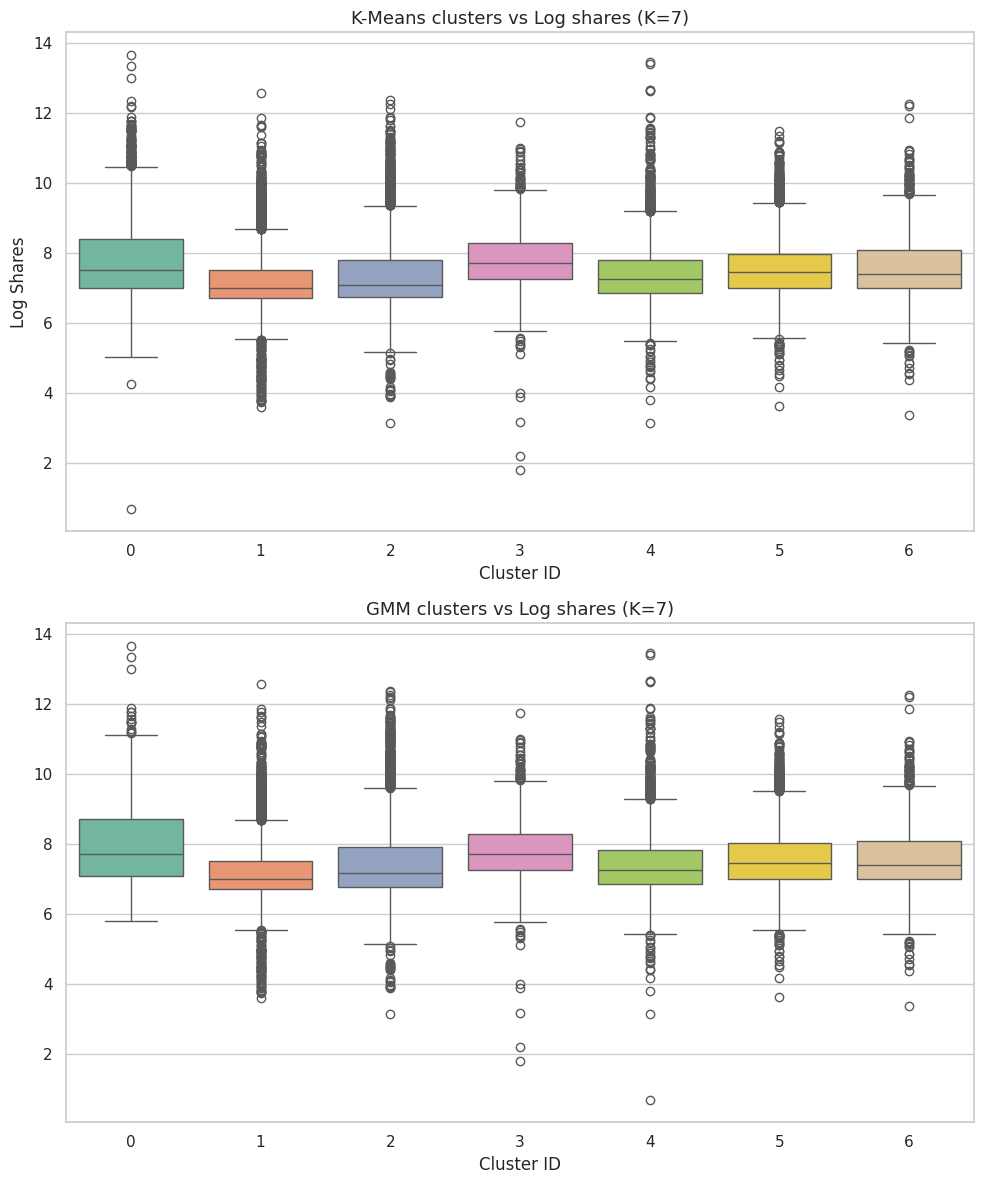

Median log shares per K-Means cluster:
KMeans_Cluster
0    7.496097
1    7.003974
2    7.090910
3    7.696667
4    7.244942
5    7.438972
6    7.378384
Name: log_shares, dtype: float64

Median log shares per GMM cluster:
GMM_Cluster
0    7.696667
1    7.003974
2    7.170888
3    7.696667
4    7.244942
5    7.438972
6    7.378384
Name: log_shares, dtype: float64


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharey=True)

# Plot K-Means target distribution
sns.boxplot(x='KMeans_Cluster', y='log_shares', data=df_clusters, palette='Set2', ax=axes[0])
axes[0].set_title(f'K-Means clusters vs Log shares (K={optimal_k})', fontsize=13)
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Log Shares')

# Plot GMM target distribution
sns.boxplot(x='GMM_Cluster', y='log_shares', data=df_clusters, palette='Set2', ax=axes[1])
axes[1].set_title(f'GMM clusters vs Log shares (K={optimal_k})', fontsize=13)
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Calculate median target values per cluster
print("Median log shares per K-Means cluster:")
print(df_clusters.groupby('KMeans_Cluster')['log_shares'].median())

print("\nMedian log shares per GMM cluster:")
print(df_clusters.groupby('GMM_Cluster')['log_shares'].median())

We can see that boxplots and the calculated medians show multiple insights regarding the relationship between the dataset's variance and article popularity:

* **Overlapping target distributions:** For both K-Means and GMM, the IQRs of `log_shares` overlap almost across all clusters. The median log shares shows very low variance between groups, ranging between ~7.0 and ~7,7. This indicates that articles with similar characteristics are not assigned into popular or unpopular groups.

* **Algorithm similarity (K-Means vs GMM):** Both algorithms produced nearly identical results, showing highly similar distributions relative to the target variable. The flexibility of GMM did not lead to better clustering results isolating the target variable that K-Means.

* **Viral articles:** The positive outliers (articles with `log_shares` > 10, representing viral content) are placed across every cluster in both models. The algorithms failed to isolate specific viral articles, proving that the popularity of these articles is caused by underlying factors not captured by the features.

**Conclusion:**
The clustering analysis shows that articles do not group together naturally based on their popularity. This means we cannot use simple categories to predict how many shares an article will get. The lack of target alignment confirms that predicting `log_shares` is a highly complex task dependent on non-linear interactions between specific features rather than simple structural groupings. 